In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer


from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer
from models.whitener import Whitener


random_seed = 0
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    'hidden_padding': None,
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
    'whitener': Whitener(64, 0.0),
}

base_model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

# model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
# model.load_state_dict(torch.load('runs/whitened/stable_decay.0005_seed0/model_weights.pth'))
# model.to(device);
# model.train();

In [3]:
# decays = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064]
decays = [0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, 0.128]
paths = [
    # 'runs/whitened/stable_decay.0005_seed0/model_weights.pth',
    # 'runs/whitened/stable_decay.001_seed0/model_weights.pth',
    # 'runs/whitened/stable_decay.002_seed0/model_weights.pth',
    # 'runs/whitened/stable_decay.004_seed0/model_weights.pth',
    # 'runs/whitened/stable_decay.008_seed0/model_weights.pth',
    # 'runs/whitened/stable_decay.016_seed0/model_weights.pth',
    # 'runs/whitened/stable_decay.032_seed0/model_weights.pth',
    # 'runs/whitened/stable_decay.064_seed0/model_weights.pth',

    'runs/whitened/l1only_decay.001_seed0/model_weights.pth',
    'runs/whitened/l1only_decay.002_seed0/model_weights.pth',
    'runs/whitened/l1only_decay.004_seed0/model_weights.pth',
    'runs/whitened/l1only_decay.008_seed0/model_weights.pth',
    'runs/whitened/l1only_decay.016_seed0/model_weights.pth',
    'runs/whitened/l1only_decay.032_seed0/model_weights.pth',
    'runs/whitened/l1only_decay.064_seed0/model_weights.pth',
    'runs/whitened/l1only_decay.128_seed0/model_weights.pth',
    
    # 'runs/whitened/active_nonlin_seed0/model_weights.pth',
    # 'runs/whitened/active_no_nonlin_seed0/model_weights.pth',
]

In [4]:
num_batches = 100
covs = []

for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()

    vecs = []

    for key in data_keys:
        batch_count = 0

        for batch in dataloaders['validation'][key]:
            batch_count += 1
            img, _, _, pupil = batch

            pred, vec = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            vecs.append(vec.detach().cpu().transpose(1, 3).flatten(0, 2))

            if batch_count == num_batches:
                break

    vecs = torch.cat(vecs)

    X = vecs
    Xc = X - X.mean(dim=0, keepdim=True)

    cov = Xc.T @ Xc / (Xc.shape[0] - 1)
    covs.append(cov)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [4]:
cov_emas = []
for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    cov_emas.append(model.readout[data_keys[0]].whitener.cov_ema.cpu())

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


0.001 	 297394.875


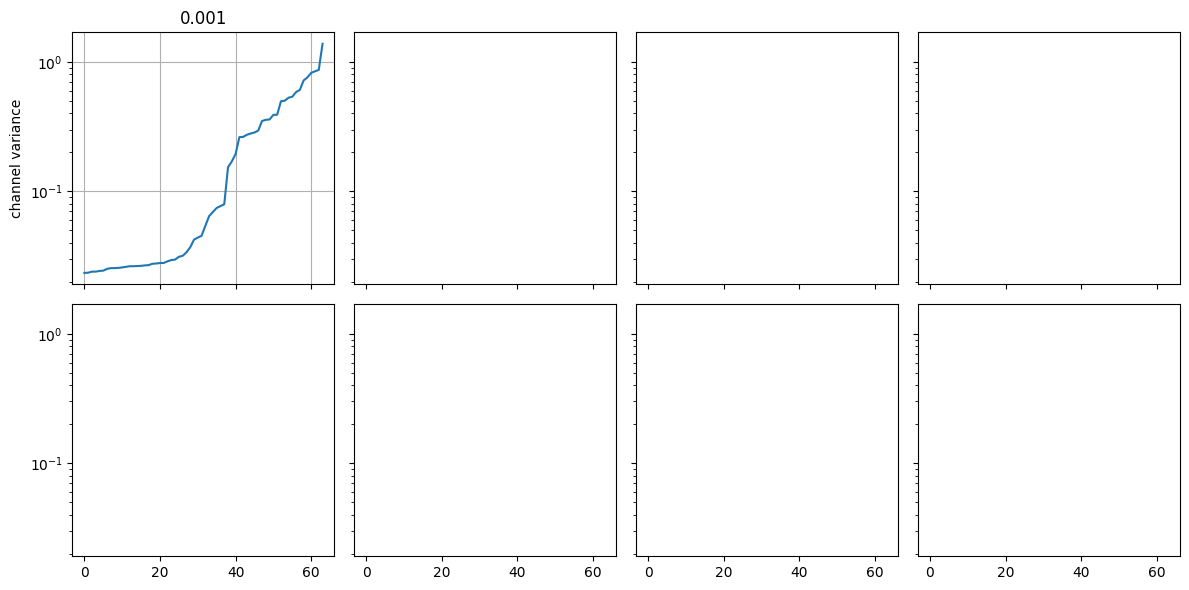

In [5]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6), sharey=True, sharex=True)

for i, (cov, label) in enumerate(zip(cov_emas, decays)):
    axs[i // 4][i % 4].plot(cov.diag().sort().values)
    axs[i // 4][i % 4].set_yscale('log')
    axs[i // 4][i % 4].set_title(label)
    axs[i // 4][i % 4].grid()
    
    if i >= 4:
        axs[i // 4][i % 4].set_xlabel('sorted channels')
    if i % 4 == 0:
        axs[i //4][i % 4].set_ylabel('channel variance')
    
    # axs[i // 4][i % 4].imshow(cov)
    # axs[i // 4][i % 4].set_xticks([])
    # axs[i // 4][i % 4].set_yticks([])
    print(label, '\t', torch.linalg.cond(cov).item())

plt.tight_layout()

In [6]:
from sensorium.utility.scores import get_correlations

scores = []
for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()

    scores.append(
        get_correlations(
            model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False 
        )
    )

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


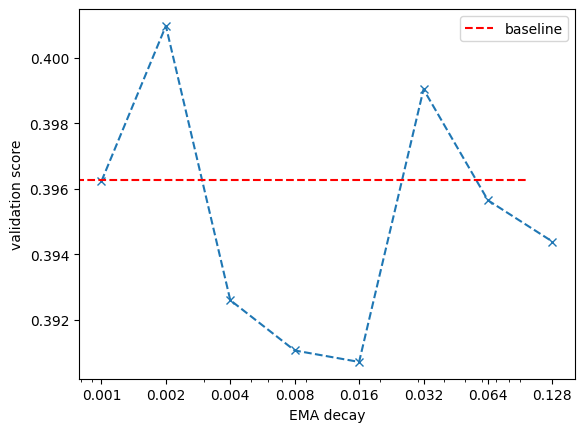

In [5]:
plt.plot(decays, scores, ls='--', marker='x')
plt.xscale('log')
plt.xticks(decays, labels=[f"{d:g}" for d in decays])
plt.hlines(0.39625624, 0, 0.1, color='r', ls='--', label='baseline')
plt.xlabel('EMA decay')
plt.ylabel('validation score')
plt.legend()
plt.show()

In [7]:
scores

[np.float32(0.3883162)]

In [8]:
basemodel = stacked_core_full_gauss_readout(dataloaders, random_seed, **base_model_config)
basemodel.load_state_dict(torch.load('runs/newbase/dim64_seed0/model_weights.pth', map_location=device))
basemodel.to(device);
basemodel.train();

train_feature_vecs = []

num_batches = 10

for key in data_keys:
    batch_count = 0
    for batch in dataloaders['train'][key]:
        batch_count += 1
        img, _, _, pupil = batch
        
        pred, feature_vec = basemodel(img, data_key=key, pupil_center=pupil, return_vec=True)
        train_feature_vecs.append(feature_vec.detach().cpu().transpose(1, 3).flatten(0, 2))

        if batch_count == num_batches:
            break

# whiten based on feature maps
X_train = torch.cat(train_feature_vecs)

# compute cov
mu = X_train.mean(dim=0, keepdims=True)
Xc = X_train - mu
cov = Xc.T @ Xc / (Xc.shape[0] - 1)

# get whitening matrix from cov
L = torch.linalg.cholesky(cov)
Winv = L.T
W = Winv.inverse()

feature_maps = []
val_feature_vecs = []

for key in data_keys:
    single_maps = []

    for batch in dataloaders['validation'][key]:
        img, _, _, pupil = batch
        
        pred, feature_vec = basemodel(img, data_key=key, pupil_center=pupil, return_vec=True)
        
        val_feature_vecs.append(feature_vec.detach().cpu().transpose(1, 3).flatten(0, 2))
    
X_val = torch.cat(val_feature_vecs)

Xw = (X_val - mu) @ W
Xwc = Xw - Xw.mean(0, keepdim=True)
base_cov = Xwc.T @ Xwc / (Xwc.shape[0] - 1)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


/tmp/ipykernel_2885589/3265623292.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


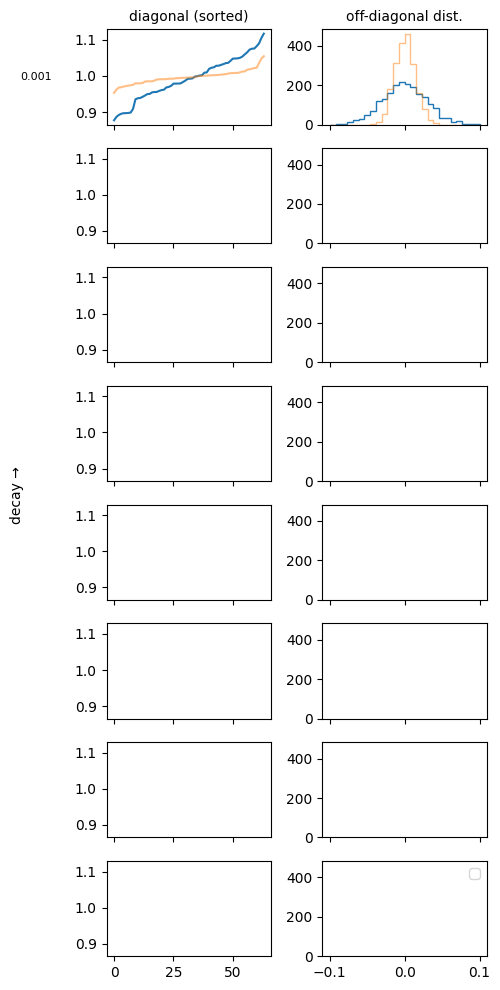

In [9]:
fig, axs = plt.subplots(8, 2, figsize=(5, 10),
                        sharex='col', 
                        sharey='col'
                        )

i, j = torch.tril_indices(64, 64, -1)
bins = np.linspace(-0.1, 0.1, 27)

for cov, row, label in zip(covs, axs, decays):
    # --- left: sorted diagonal ---
    row[0].plot(cov.diag().sort().values)
    row[0].plot(base_cov.diag().sort().values, alpha=0.5)
    row[0].set_ylabel(f"{label:.3f}", fontsize=8, rotation=0,
                      labelpad=28, va='center')

    # --- right: off-diagonal histogram ---
    row[1].hist(cov[i, j], bins=bins, histtype='step')
    row[1].hist(base_cov[i, j], bins=bins, histtype='step', alpha=0.5)

# axs[-1][0].plot(base_cov.diag().sort().values)
# axs[-1][0].set_ylabel(f"post-hoc", fontsize=8, rotation=0,
#                       labelpad=28, va='center')

# axs[-1][1].hist(base_cov[i, j], bins=bins)

# column titles
axs[0][0].set_title("diagonal (sorted)", fontsize=10)
axs[0][1].set_title("off-diagonal dist.", fontsize=10)

# shared row labels
fig.text(0.01, 0.5, "decay →", va='center', rotation='vertical', fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

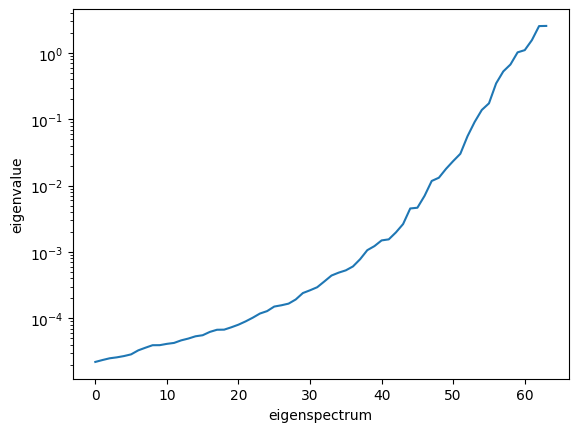

In [29]:
cov = model.readout[data_keys[0]].whitener.cov_ema.cpu()
eigvals = torch.linalg.eigh(cov).eigenvalues
plt.plot(eigvals)
plt.yscale('log')
plt.xlabel('eigenspectrum')
plt.ylabel('eigenvalue')
plt.show()

# kNN

In [6]:
regws = [1, 2, 3, 6, 12, 24]
reg_paths = [
    [
        'runs/whitened/regw1_seed0/model_weights.pth',
        'runs/whitened/regw1_seed42/model_weights.pth',
        'runs/whitened/regw1_seed123/model_weights.pth',
    ],
    [
        'runs/whitened/regw2_seed0/model_weights.pth',
        'runs/whitened/regw2_seed42/model_weights.pth',
        'runs/whitened/regw2_seed123/model_weights.pth',
    ],
    [
        'runs/whitened/regw3_seed0/model_weights.pth',
        'runs/whitened/regw3_seed42/model_weights.pth',
        'runs/whitened/regw3_seed123/model_weights.pth',
    ],
    [
        'runs/whitened/regw6_seed0/model_weights.pth',
        'runs/whitened/regw6_seed42/model_weights.pth',
        'runs/whitened/regw6_seed123/model_weights.pth',
    ],
    [
        'runs/whitened/regw12_seed0/model_weights.pth',
        'runs/whitened/regw12_seed42/model_weights.pth',
        'runs/whitened/regw12_seed123/model_weights.pth',
    ],
    [
        'runs/whitened/regw24_seed0/model_weights.pth',
        'runs/whitened/regw24_seed42/model_weights.pth',
        'runs/whitened/regw24_seed123/model_weights.pth',
    ]
]

# reg_paths = [
#     [
#         'runs/whitened/warmup_reg3_seed0/model_weights.pth',
#         'runs/whitened/warmup_reg3_seed42/model_weights.pth',
#         'runs/whitened/warmup_reg3_seed123/model_weights.pth',
#     ],
#     [
#         'runs/whitened/warmup_reg6_seed0/model_weights.pth',
#         'runs/whitened/warmup_reg6_seed42/model_weights.pth',
#         'runs/whitened/warmup_reg6_seed123/model_weights.pth',
#     ],
#     [
#         'runs/whitened/warmup_reg12_seed0/model_weights.pth',
#         'runs/whitened/warmup_reg12_seed42/model_weights.pth',
#         'runs/whitened/warmup_reg12_seed123/model_weights.pth',
#     ],
#     [
#         'runs/whitened/warmup_reg24_seed0/model_weights.pth',
#         'runs/whitened/warmup_reg24_seed42/model_weights.pth',
#         'runs/whitened/warmup_reg24_seed123/model_weights.pth',
#     ]
# ]

# regws = [1.5, 3, 6]
# reg_paths = [
#     [
#         'runs/whitened/p0.5_regw1.5_seed0/model_weights.pth',
#         'runs/whitened/p0.5_regw1.5_seed42/model_weights.pth',
#         'runs/whitened/p0.5_regw1.5_seed123/model_weights.pth',
#     ],
#     [
#         'runs/whitened/p0.5_regw3_seed0/model_weights.pth',
#         'runs/whitened/p0.5_regw3_seed42/model_weights.pth',
#         'runs/whitened/p0.5_regw3_seed123/model_weights.pth',
#     ],
#     [
#         'runs/whitened/p0.5_regw6_seed0/model_weights.pth',
#         'runs/whitened/p0.5_regw6_seed42/model_weights.pth',
#         'runs/whitened/p0.5_regw6_seed123/model_weights.pth',
#     ],
# ]

In [3]:
import utils.knn as knn

k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
curves = []

for paths in reg_paths:
    all_readouts = []

    for path in paths:
        all_readouts.append([])

        model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
        model.train()

        for key in data_keys:
            readouts = model.readout[key].features
            readouts = model.readout[key].whitener.whiten_readouts(readouts)
            readouts = readouts.detach().cpu().squeeze().T

            all_readouts[-1].append(readouts)

        all_readouts[-1] = torch.cat(all_readouts[-1])
        
    curves.append(knn.get_curve(all_readouts, k_range))

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnor

In [4]:
import utils.knn as knn

base_paths = [
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

num_batches = 10
k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
all_readouts = []

for path in base_paths:
    basemodel = stacked_core_full_gauss_readout(dataloaders, random_seed, **base_model_config)
    basemodel.load_state_dict(torch.load(path, map_location=device))
    basemodel.to(device)
    basemodel.train()

    train_feature_vecs = []

    for key in data_keys:
        batch_count = 0
        for batch in dataloaders['train'][key]:
            batch_count += 1
            img, _, _, pupil = batch
            
            pred, feature_vec = basemodel(img, data_key=key, pupil_center=pupil, return_vec=True)
            train_feature_vecs.append(feature_vec.detach().cpu().transpose(1, 3).flatten(0, 2))

            if batch_count == num_batches:
                break

    # whiten based on feature maps
    X_train = torch.cat(train_feature_vecs)

    # compute cov
    mu = X_train.mean(dim=0, keepdims=True)
    Xc = X_train - mu
    cov = Xc.T @ Xc / (Xc.shape[0] - 1)

    # get whitening matrix from cov
    L = torch.linalg.cholesky(cov)
    Winv = L.T

    readouts = torch.cat([(Winv @ basemodel.readout[key].features.detach().cpu().squeeze()).T for key in data_keys])
    all_readouts.append(readouts)
    
base_curve = knn.get_curve(all_readouts, k_range)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


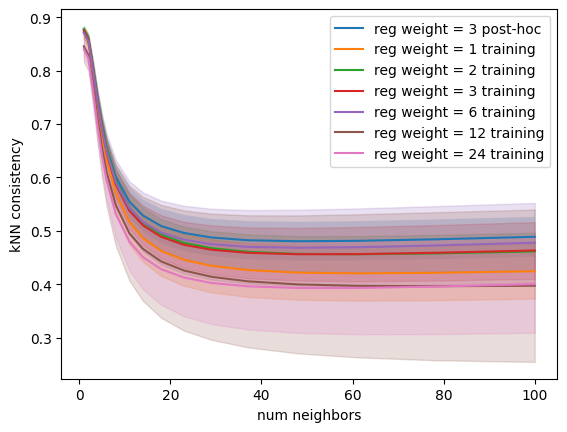

In [13]:
# Get the default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

m = base_curve[0]
s = base_curve[1]
plt.plot(k_range, m, color=colors[0], label='reg weight = 3 post-hoc')
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

for curve, label, color in zip(curves, regws, colors[1:7]):
    m = curve[0]
    s = curve[1]
    plt.plot(k_range, m, color=color, label='reg weight = ' + str(label) + ' training')
    plt.fill_between(k_range, m - s, m + s, alpha=0.2, color=color)

plt.legend()
plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.show()

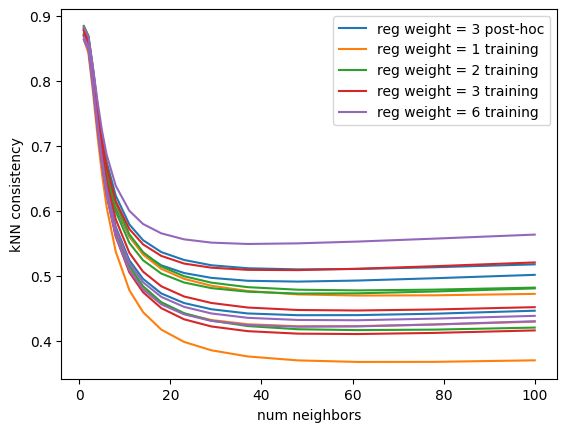

In [10]:
# Get the default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

labeled = False
for curve in base_curve[2].T:
    plt.plot(k_range, curve, color=colors[0], label='reg weight = 3 post-hoc' if not labeled else None)
    labeled = True

for three_curves, label, color in zip(curves, regws, colors[1:5]):
    labeled = False
    for curve in three_curves[2].T:
        plt.plot(k_range, curve, color=color, label='reg weight = ' + str(label) + ' training' if not labeled else None)
        labeled = True
    


plt.legend()
plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.show()

In [9]:
from sensorium.utility.scores import get_correlations

base_scores = []

for path in base_paths:
    basemodel = stacked_core_full_gauss_readout(dataloaders, random_seed, **base_model_config)
    basemodel.load_state_dict(torch.load(path, map_location=device))
    basemodel.to(device)
    basemodel.train()

    score = get_correlations(basemodel, dataloaders['validation'], device=device, as_dict=False, per_neuron=False)
    base_scores.append(score)

reg_scores = []

for paths in reg_paths:
    reg_scores.append([])
    for path in paths:
        model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
        model.train()

        score = get_correlations(model, dataloaders['validation'], device=device, as_dict=False, per_neuron=False)
        reg_scores[-1].append(score)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

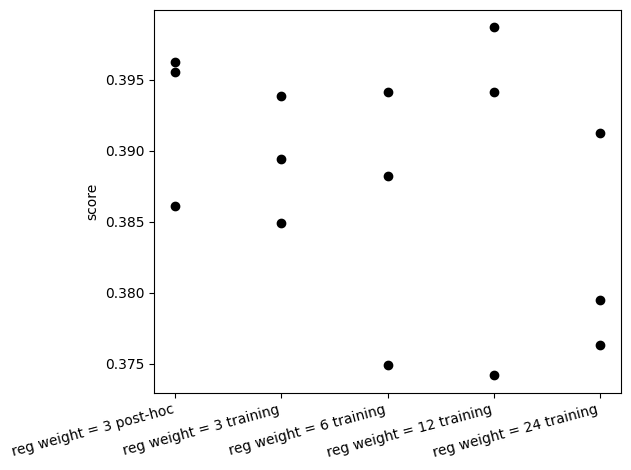

In [10]:
labels = ['reg weight = 3 post-hoc'] + ['reg weight = ' + str(w) + ' training' for w in regws]
all_scores = np.concatenate([np.array(base_scores)[None], np.array(reg_scores)])

for i, scores in enumerate(all_scores):
    plt.scatter([i, i, i], scores, c='black')

plt.xticks(range(len(labels)), labels, rotation=15, ha='right')
plt.ylabel('score')
plt.tight_layout()
plt.show()

In [ ]:
all_readouts[0].shape

torch.Size([54569, 64])

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


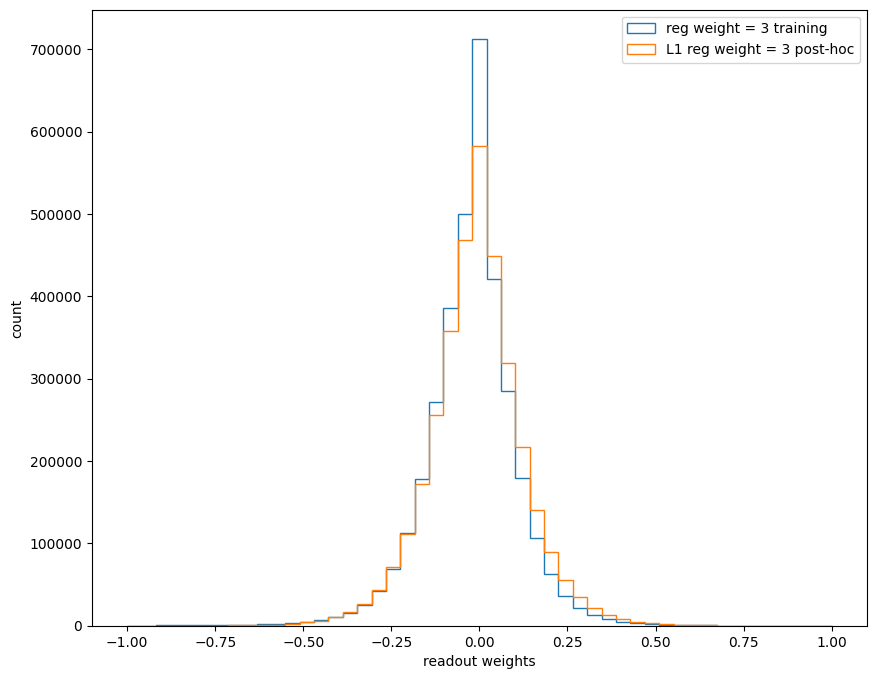

In [40]:
plt.figure(figsize=(10, 8))
bins = np.linspace(-1, 1, 50)

for path, label in zip(reg_paths[::-1], regws[::-1]):
    if label != 3: continue
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path[0], map_location=device))
    model.to(device)
    model.train()

    readouts = []
    for key in data_keys:
        r = model.readout[key].features
        r = model.readout[key].whitener.whiten_readouts(r)
        readouts.append(r)
    readouts = torch.cat(readouts, dim=-1)
    readouts = readouts.detach().cpu().flatten()

    plt.hist(readouts, histtype='step', bins=bins, label='reg weight = ' + str(label) + ' training')

# basemodel = stacked_core_full_gauss_readout(dataloaders, random_seed, **base_model_config)
# basemodel.load_state_dict(torch.load(base_paths[0], map_location=device))
# basemodel.to(device)
# basemodel.train()
# readouts = torch.cat([basemodel.readout[key].features.detach().cpu().flatten() for key in data_keys])
readouts = all_readouts[0].flatten()

plt.hist(readouts, histtype='step', bins=bins, label='L1 reg weight = 3 post-hoc')

plt.xlabel('readout weights')
plt.ylabel('count')
plt.legend()
plt.show()

In [89]:
1 / (2 * 1e-3**(1/2))

15.811388300841898